Un propietario de una casa rural está buscando formas de regar un pequeño huerto familiar. 

Una posibilidad que se está considerando es utilizar el agua de un pequeño arroyo que está a 38 mts de distancia del jardín y 8 mts más abajo que el jardín. 

Determine las especificaciones para un sistema de bombas y tuberías que suministre agua de riego al jardín a un caudal de 20 litros por minuto.

In [1]:
import CoolProp.CoolProp as cp
import fluids as fld
import numpy as np

Datos

In [2]:
z = 8  #mts

L = 38 #mts

V_dot_lm = 20 # lts/min
V_dot = V_dot_lm/(1000 * 60) # lts/min

Para suministrar el agua de riego al jardín, la bomba debe suministrar suficiente presión para superar (1) la diferencia de altitud y (2) los efectos de fricción en la red de tuberías de la red,

$\Delta P_{\text {pump}}=\Delta P_{\text{elevation}}+\Delta P_{\text{friction}}$


El aumento de presión necesario para superar la diferencia de altitud es

$ \Delta P_{\text{elevation}}= \rho g z $



In [3]:
fluid = 'water'
P_o = 101325
T_o = 25 + 273.15
rho = cp.PropsSI("D", "T", T_o, "P", P_o, fluid)
mu = cp.PropsSI("V","T", T_o, "P", P_o, fluid)

In [4]:
g = 9.8 
DELTA_P_e = rho * g * z

DELTA_P_e

78168.53472201122

La pérdida de carga debido a la fricción puede calcularse realizando un análisis de la fricción de la tubería,

$\Delta P_{\text{friction}} =f \frac{L}{D} \frac{\rho V^{2}}{2}$

La velocidad en la tubería es una función del caudal y del diámetro de la tubería,

$V=\frac{\dot{V}}{A}=\frac{4 \dot{V}}{\pi D^{2}}$

Sustituyendo esta expresión en la ecuación de la caída de presión por fricción se obtiene

$\Delta P_{\text {friction }}=f \frac{8 \rho L \dot{V}^{2}}{\pi^{2} D^{5}}$

In [5]:
D = 0.02
A_D = (np.pi * D**2)/4
V = V_dot / A_D
Re = fld.Reynolds(D, rho, V, mu)


In [6]:
epsilon = fld.roughness_Farshad('Plastic coated', D)
f = fld.friction.friction_factor(Re, eD=epsilon/D)
f

0.025419834653613246

In [7]:
DELTA_P_f = (f * 8 * rho * (L + z) * V_dot**2)/(np.pi**2 * D**5)
DELTA_P_f

32812.86980148238

In [8]:
Delta_P = DELTA_P_f + DELTA_P_e
Delta_P

110981.4045234936

**Análisis de Sensibilidad**

vectorized module wraps all of the fluids functions with np.vectorize

---> also explore fluids.numba_vectorized 

In [9]:
from fluids.vectorized import * 

In [10]:
D_range = np.linspace(6, 65, 100) /1000

A_range = (np.pi * D_range**2)/4
V_range = V_dot / A_range
Re_range = Reynolds(D_range, rho, V_range, mu)

epsilon_range = roughness_Farshad('Plastic coated', D_range)
eD_range = epsilon_range/D_range

In [11]:
f_range = friction_factor(Re=Re_range, eD=eD_range) 

f_range

array([0.02224776, 0.02224688, 0.02228848, 0.02236171, 0.02245865,
       0.02257337, 0.02270147, 0.02283955, 0.02298507, 0.02313603,
       0.02329089, 0.02344845, 0.02360778, 0.02376814, 0.02392895,
       0.02408975, 0.02425018, 0.02440996, 0.02456886, 0.02472671,
       0.02488338, 0.02503876, 0.02519277, 0.02534537, 0.0254965 ,
       0.02564614, 0.02579427, 0.0259409 , 0.02608601, 0.02622961,
       0.02637172, 0.02651235, 0.02665151, 0.02678922, 0.0269255 ,
       0.02706038, 0.02719389, 0.02732603, 0.02745685, 0.02758635,
       0.02771458, 0.02784154, 0.02796728, 0.0280918 , 0.02821514,
       0.02833732, 0.02845837, 0.0285783 , 0.02869714, 0.02881491,
       0.02893163, 0.02904733, 0.02916203, 0.02927573, 0.02938848,
       0.02950028, 0.02961115, 0.02972111, 0.02983018, 0.02993838,
       0.03004572, 0.03015222, 0.0302579 , 0.03036277, 0.03046685,
       0.03057014, 0.03067268, 0.03077446, 0.03087551, 0.03097584,
       0.03107546, 0.03117438, 0.03127261, 0.03137017, 0.03146

In [13]:
DELTA_P_f_range = (f_range * 8 * rho * (L + z) * V_dot**2)/(np.pi**2 * D_range**5)

DELTA_P_f_range

array([1.18182022e+07, 7.36038640e+06, 4.78495507e+06, 3.22426431e+06,
       2.23970366e+06, 1.59692724e+06, 1.16468812e+06, 8.66438464e+05,
       6.55929619e+05, 5.04340217e+05, 3.93210366e+05, 3.10424494e+05,
       2.47855032e+05, 1.99941104e+05, 1.62809375e+05, 1.33717701e+05,
       1.10695703e+05, 9.23081190e+04, 7.74962647e+04, 6.54701234e+04,
       5.56337952e+04, 4.75332909e+04, 4.08195056e+04, 3.52216463e+04,
       3.05279514e+04, 2.65715549e+04, 2.32200231e+04, 2.03675386e+04,
       1.79290114e+04, 1.58356065e+04, 1.40313213e+04, 1.24703471e+04,
       1.11150213e+04, 9.93422834e+03, 8.90214215e+03, 7.99723257e+03,
       7.20147510e+03, 6.49971952e+03, 5.87918258e+03, 5.32903863e+03,
       4.84008754e+03, 4.40448429e+03, 4.01551769e+03, 3.66742872e+03,
       3.35526066e+03, 3.07473510e+03, 2.82214887e+03, 2.59428823e+03,
       2.38835698e+03, 2.20191622e+03, 2.03283363e+03, 1.87924059e+03,
       1.73949599e+03, 1.61215536e+03, 1.49594470e+03, 1.38973810e+03,
      

In [14]:
Delta_P_range = DELTA_P_f_range + DELTA_P_e
Delta_P_range


array([11896370.77167708,  7438554.93484424,  4863123.60254573,
        3302432.84578077,  2317872.19393186,  1675095.77352915,
        1242856.6577634 ,   944606.99880783,   734098.15378424,
         582508.75148345,   471378.90037838,   388593.02902283,
         326023.56629653,   278109.63865269,   240977.90943383,
         211886.2356793 ,   188864.23822002,   170476.65370244,
         155664.79937761,   143638.65811225,   133802.32992034,
         125701.82561291,   118988.04028026,   113390.18104803,
         108696.48614048,   104740.08960599,   101388.55781337,
          98536.07330517,    96097.54609982,    94004.14124665,
          92199.85607156,    90638.8818237 ,    89283.55604136,
          88102.76305962,    87070.6768748 ,    86165.76729179,
          85370.00982562,    84668.25423949,    84047.71730247,
          83497.57335152,    83008.62226411,    82573.01900794,
          82184.05240879,    81835.9634395 ,    81523.79538406,
          81243.26981944,    80990.68359

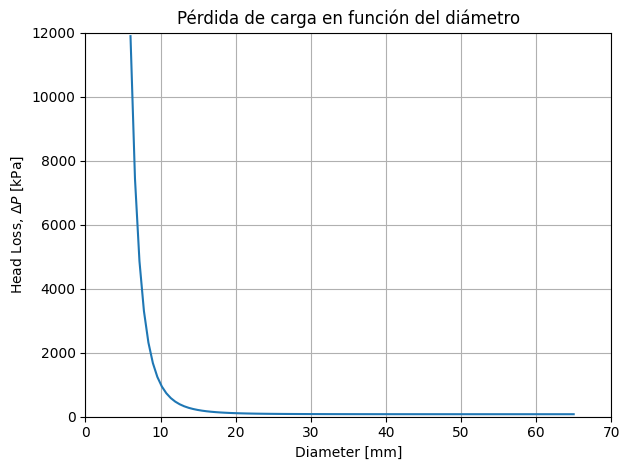

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(D_range * 1000, Delta_P_range/1000)
plt.xlabel("Diameter [mm]")
plt.ylabel(r"Head Loss, $\Delta P$ [kPa]")
plt.title("Pérdida de carga en función del diámetro")
plt.xlim([0, 70])
plt.ylim([0, 12000])
plt.grid(True)
plt.tight_layout()

#iterar en un loop. Proghramación de fluids no permite calcular factor de fricción de un vector (operación booleana)
f_range =  np.empty([0])
for D in D_range:
    V = (4*V_dot) / (np.pi * D**2)
    Re = fld.Reynolds(D, rho, V, mu)
    epsilon = fld.roughness_Farshad('Plastic coated', D)
    f_range = np.append([f_range], [fld.friction.friction_factor(Re, eD=epsilon/D)])
f_range